# 6-Layer Decoder-Only Transformer for Shakespeare-Style Text Generation

## Abstract

This report presents the implementation, training, and analysis of a 6-layer decoder-only Transformer for autoregressive Shakespeare-style text generation. The model is implemented in PyTorch and trained on a TinyShakespeare corpus using a Llama 2 tokenizer. The study focuses on both the practical implementation of the Transformer architecture and the quantitative analysis of its parameter count and computational cost.

The implemented architecture includes token embeddings, rotary positional embeddings (RoPE), LayerNorm, causal masked multi-head self-attention, feed-forward networks, and a language modeling head. The report also provides layer-level parameter accounting, FLOPs estimation, training-loss visualization, and qualitative generation results.

## 1. Experimental Environment

All experiments were conducted in a project-local Python environment. The implementation uses PyTorch with CUDA support when an available GPU is detected. The environment was fixed through `requirements.txt` to make the experiment reproducible, with Python 3.11, PyTorch CUDA 12.8 wheels, Hugging Face Transformers, ModelScope, Matplotlib, Pandas, and Jupyter.

The notebook automatically selects the GPU with the largest amount of free memory. This avoids accidental allocation on a heavily occupied GPU and makes the experiment more robust on shared servers.

In [1]:
from pathlib import Path
import math
import random
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer

from src.shakespeare_transformer import (
    TransformerConfig,
    ShakespeareTransformer,
    apply_rope,
    build_causal_mask,
    estimate_flops_by_layer,
    experimental_parameter_count,
    theoretical_parameter_count,
)

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
TOKENIZER_DIR = ROOT / "tokenizer" / "llama-2-7b-hf"
DATA_PATH = DATA_DIR / "tinyshakespeare.txt"

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def pick_device():
    if not torch.cuda.is_available():
        return torch.device("cpu")
    import subprocess
    try:
        result = subprocess.run(
            [
                "nvidia-smi",
                "--query-gpu=index,memory.free,memory.total",
                "--format=csv,noheader,nounits",
            ],
            check=True,
            capture_output=True,
            text=True,
        )
        rows = []
        for line in result.stdout.strip().splitlines():
            idx, free_mb, total_mb = [part.strip() for part in line.split(",")]
            rows.append((int(free_mb), int(total_mb), int(idx)))
        free_mb, total_mb, best_idx = max(rows)
        print("GPU free memory from nvidia-smi:")
        for free_i, total_i, idx_i in rows:
            print(f"  cuda:{idx_i}: {free_i / 1024:.1f} GiB free / {total_i / 1024:.1f} GiB total")
        torch.cuda.set_device(best_idx)
        return torch.device(f"cuda:{best_idx}")
    except Exception as exc:
        print("Could not query nvidia-smi, falling back to cuda:0:", exc)
        return torch.device("cuda:0")

# Override manually if needed, for example: device = torch.device("cuda:4")
device = pick_device()
print("device:", device)
print("torch:", torch.__version__, "cuda runtime:", torch.version.cuda)

/mlp-01/hexuming/machine-learning-course-project/.venv/lib/python3.11/site-packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


GPU free memory from nvidia-smi:
  cuda:0: 0.3 GiB free / 95.6 GiB total
  cuda:1: 0.3 GiB free / 95.6 GiB total
  cuda:2: 0.3 GiB free / 95.6 GiB total
  cuda:3: 0.3 GiB free / 95.6 GiB total
  cuda:4: 95.2 GiB free / 95.6 GiB total
  cuda:5: 95.2 GiB free / 95.6 GiB total
  cuda:6: 95.2 GiB free / 95.6 GiB total
  cuda:7: 95.2 GiB free / 95.6 GiB total
device: cuda:7
torch: 2.7.1+cu128 cuda runtime: 12.8


## 2. Dataset

The text corpus used in this experiment is TinyShakespeare, a compact dataset derived from Shakespeare's plays and commonly used for character- and token-level language modeling experiments. The corpus contains dialogue, speaker names, line breaks, and archaic vocabulary, making it suitable for evaluating whether a small autoregressive model can learn stylistic patterns of Shakespearean text.

The notebook reads `data/tinyshakespeare.txt` from the local project directory. If the file is absent, it downloads the public TinyShakespeare text mirror used in many language-modeling baselines.

In [2]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
if not DATA_PATH.exists():
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    print("Downloading TinyShakespeare fallback text...")
    urllib.request.urlretrieve(url, DATA_PATH)

text = DATA_PATH.read_text(encoding="utf-8")
print(f"characters: {len(text):,}")
print(text[:500])

characters: 1,115,394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 3. Tokenizer

The text is tokenized with the Llama 2 tokenizer from the ModelScope model `shakechen/Llama-2-7b-hf`. Only tokenizer files are used; no pretrained model weights are loaded. This satisfies the assignment requirement of using a Llama 2 tokenizer while keeping the Transformer model itself trained from scratch.

Using a subword tokenizer gives the model a fixed vocabulary and avoids the extremely long sequences that would result from pure character-level modeling. The same tokenizer is also used to decode generated token sequences back into text for qualitative evaluation.

In [3]:
def ensure_tokenizer_files():
    if TOKENIZER_DIR.exists() and any(TOKENIZER_DIR.iterdir()):
        return TOKENIZER_DIR
    try:
        from modelscope.hub.snapshot_download import snapshot_download
        TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)
        snapshot_download(
            "shakechen/Llama-2-7b-hf",
            local_dir=str(TOKENIZER_DIR),
            allow_file_pattern=[
                "tokenizer.model",
                "tokenizer.json",
                "tokenizer_config.json",
                "special_tokens_map.json",
                "added_tokens.json",
            ],
        )
        return TOKENIZER_DIR
    except Exception as exc:
        raise RuntimeError(
            "Llama 2 tokenizer files are missing. Run `python scripts/download_assets.py` "
            "or place the tokenizer files under tokenizer/llama-2-7b-hf."
        ) from exc

tokenizer_path = ensure_tokenizer_files()
tokenizer = AutoTokenizer.from_pretrained(tokenizer_path, use_fast=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
print("vocab size:", len(tokenizer))
print("bos/eos/pad:", tokenizer.bos_token_id, tokenizer.eos_token_id, tokenizer.pad_token_id)

vocab size: 32000
bos/eos/pad: 1 2 2


## 4. Tokenization and Batch Construction

The complete text is encoded into a single sequence of token IDs and split into training and validation partitions with a 90/10 ratio. Each training example is a contiguous window of length `block_size`. For autoregressive language modeling, the input sequence is the token window excluding the final token, while the target sequence is shifted one position to the right.

This construction trains the model to estimate the conditional distribution of the next token given all previous tokens within the context window.

In [4]:
all_ids = tokenizer.encode(text, add_special_tokens=False)
print(f"tokens: {len(all_ids):,}")

split = int(0.9 * len(all_ids))
train_ids = torch.tensor(all_ids[:split], dtype=torch.long)
val_ids = torch.tensor(all_ids[split:], dtype=torch.long)

class TokenWindowDataset(Dataset):
    def __init__(self, ids: torch.Tensor, block_size: int):
        self.ids = ids
        self.block_size = block_size

    def __len__(self):
        return max(0, len(self.ids) - self.block_size - 1)

    def __getitem__(self, idx):
        chunk = self.ids[idx : idx + self.block_size + 1]
        return chunk[:-1], chunk[1:]

BLOCK_SIZE = 128
BATCH_SIZE = 16
train_ds = TokenWindowDataset(train_ids, BLOCK_SIZE)
val_ds = TokenWindowDataset(val_ids, BLOCK_SIZE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
print(len(train_ds), len(val_ds))

tokens: 368,633
331640 36735


## 5. Model Architecture

The implemented model is a decoder-only Transformer trained from scratch. Positional information is introduced through RoPE inside the attention mechanism rather than through learned absolute positional embeddings. The architecture contains six Transformer blocks, as required by the assignment.

Each block follows a pre-normalization design: LayerNorm is applied before causal self-attention and before the feed-forward network. The attention module projects hidden states into queries, keys, and values, applies RoPE to queries and keys, masks future positions with a causal mask, and projects the attended representation back to the model dimension. The feed-forward network uses a GELU nonlinearity between two linear transformations.

A final LayerNorm and a linear language modeling head map the hidden states to vocabulary logits.

In [5]:
config = TransformerConfig(
    vocab_size=len(tokenizer),
    max_seq_len=BLOCK_SIZE,
    n_layers=6,
    n_heads=6,
    d_model=384,
    d_ff=1536,
    dropout=0.1,
)
model = ShakespeareTransformer(config).to(device)
print(model)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

ShakespeareTransformer(
  (token_embedding): Embedding(32000, 384)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x TransformerBlock(
      (ln_1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadCausalSelfAttention(
        (q_proj): Linear(in_features=384, out_features=384, bias=True)
        (k_proj): Linear(in_features=384, out_features=384, bias=True)
        (v_proj): Linear(in_features=384, out_features=384, bias=True)
        (out_proj): Linear(in_features=384, out_features=384, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1536, out_features=384, bias=True)
          (3): Dropout

## 6. Parameter Count Analysis

The theoretical parameter count is computed component by component. The accounting includes token embeddings, query/key/value/output attention projections, feed-forward network weights and biases, LayerNorm affine parameters, final LayerNorm parameters, and the language modeling head.

RoPE and the causal attention mask do not introduce trainable parameters. Therefore, they affect computation and model behavior but not the parameter count.

In [6]:
param_summary = theoretical_parameter_count(config)
pd.DataFrame([{"component": k, "parameters": v} for k, v in param_summary.items()])

,component,parameters
0,token_embedding,12288000
1,attention_per_block,591360
2,layernorms_per_block,1536
3,ffn_per_block,1181568
4,block_total,1774464
5,all_blocks,10646784
6,final_layernorm,768
7,lm_head,12288000
8,total,35223552


In [7]:
exp_params = pd.DataFrame(experimental_parameter_count(model))
exp_params.tail(10)

,module,parameters
42,blocks.5.attn.q_proj,147840
43,blocks.5.attn.k_proj,147840
44,blocks.5.attn.v_proj,147840
45,blocks.5.attn.out_proj,147840
46,blocks.5.ln_2,768
47,blocks.5.ffn.net.0,591360
48,blocks.5.ffn.net.2,590208
49,final_ln,768
50,lm_head,12288000
51,total,35223552


## 7. FLOPs Analysis

The FLOPs estimate uses standard multiply-add accounting. A linear layer with input dimension `m` and output dimension `n` over `B x T` tokens is approximated as `2 * B * T * m * n` FLOPs. Attention score computation and value aggregation each cost approximately `2 * B * H * T^2 * D_head` FLOPs.

This estimate focuses on the dominant matrix multiplications. Operations such as softmax, dropout, GELU, sampling, and indexing are comparatively smaller and are omitted or approximated in the layer-level summary.

In [8]:
flops_table = pd.DataFrame(estimate_flops_by_layer(config, seq_len=BLOCK_SIZE, batch_size=BATCH_SIZE))
flops_table["gflops"] = flops_table["flops"] / 1e9
flops_table

,layer,flops,gflops
0,token_embedding_lookup,0,0.000000
1,transformer_block_1,7658274816,7.658275
2,transformer_block_2,7658274816,7.658275
3,transformer_block_3,7658274816,7.658275
4,transformer_block_4,7658274816,7.658275
5,transformer_block_5,7658274816,7.658275
6,transformer_block_6,7658274816,7.658275
7,final_layernorm,3932160,0.003932
8,lm_head,50331648000,50.331648
9,total,96285229056,96.285229


## 8. Training Setup

The model uses six layers, six attention heads, hidden size 384, feed-forward size 1536, context length 128, and batch size 16. This configuration satisfies the required model depth while keeping the total parameter count appropriate for TinyShakespeare and feasible for single-GPU training.

The optimizer is AdamW with learning rate `3e-4`, betas `(0.9, 0.95)`, weight decay `0.1`, and gradient clipping. These settings are commonly used for small Transformer language models because they provide stable optimization while limiting exploding gradients.

Training and validation losses are recorded periodically to evaluate optimization progress and monitor overfitting.

In [12]:
@torch.no_grad()
def estimate_loss(model, loader, max_batches=10):
    model.eval()
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return sum(losses) / max(1, len(losses))

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=0.1)
MAX_STEPS = 2000
EVAL_INTERVAL = 50
GRAD_CLIP = 1.0

history = []
model.train()
train_iter = iter(train_loader)
progress = tqdm(range(1, MAX_STEPS + 1))
for step in progress:
    try:
        x, y = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        x, y = next(train_iter)
    x, y = x.to(device), y.to(device)

    optimizer.zero_grad(set_to_none=True)
    _, loss = model(x, y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    optimizer.step()

    if step == 1 or step % EVAL_INTERVAL == 0:
        val_loss = estimate_loss(model, val_loader, max_batches=5)
        row = {"step": step, "train_loss": loss.item(), "val_loss": val_loss}
        history.append(row)
        progress.set_postfix(row)

history_df = pd.DataFrame(history)
history_df

  0%|          | 0/2000 [00:00<?, ?it/s]

,step,train_loss,val_loss
0,1,4.794764,4.837348
1,50,4.476736,4.583267
2,100,4.381712,4.515055
3,150,4.550603,4.428719
4,200,4.279124,4.329914
5,250,4.026298,4.152159
6,300,3.864408,4.043461
7,350,3.821322,3.955638
8,400,3.858382,3.877582
9,450,3.986574,3.829004


## 9. Training Loss Curve

The following plot reports the training and validation cross-entropy losses measured during training. A decreasing training loss indicates that the model is learning the autoregressive next-token prediction objective. The validation curve provides a held-out estimate of generalization to unseen portions of the Shakespeare corpus.

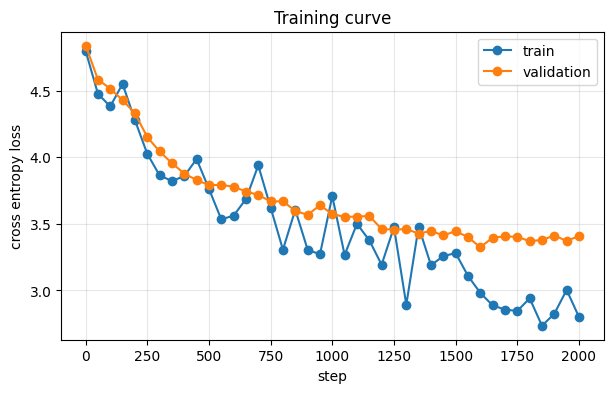

In [13]:
if len(history_df):
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["step"], history_df["train_loss"], marker="o", label="train")
    plt.plot(history_df["step"], history_df["val_loss"], marker="o", label="validation")
    plt.xlabel("step")
    plt.ylabel("cross entropy loss")
    plt.title("Training curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. Text Generation

After training, text is generated autoregressively from a short prompt. At each step, the model predicts a distribution over the next token, samples from that distribution, and appends the sampled token to the context. Temperature controls the sharpness of the sampling distribution, while top-k sampling restricts generation to the most likely candidate tokens.

In [14]:
prompt = "ROMEO:\n"
start_ids = tokenizer.encode(prompt, add_special_tokens=False)
idx = torch.tensor([start_ids], dtype=torch.long, device=device)
out = model.generate(idx, max_new_tokens=160, temperature=0.9, top_k=50)[0].tolist()
print(tokenizer.decode(out))

ROMEO:
Feseech your grace, you cannot confess,
I have deserved you; but that you do't not
Even for the loss and your honour: your enemy
Be not your honourfulness; for it is.

LEONTES:
What's he?

Servant:
But is a good queen, is already gone:
You cannot lie close my wife; and I am sorry.

POLIXENES:
The gods be here!

PAULINA:
For what comes here?

EMILIA:
You' the good queen.

LEONTES:
Why, nothing have no more.
These and the soul: then she's none but


## 11. Discussion and Conclusion

The implemented model is intentionally much smaller than modern pretrained language models because TinyShakespeare is a small corpus. A very large model would be computationally unnecessary and would likely overfit quickly. The selected 6-layer, 384-dimensional Transformer provides a reasonable balance between capacity, training cost, and dataset size.

The architecture satisfies the main Transformer components required in the assignment: token embeddings, RoPE positional encoding, LayerNorm, causal masked attention, and feed-forward networks. RoPE provides position-dependent query/key rotations without adding trainable parameters, and the causal mask enforces the autoregressive constraint by preventing each token from attending to future positions.

The parameter analysis shows that most trainable parameters are concentrated in the Transformer blocks and the vocabulary projection. The FLOPs analysis shows that attention cost grows quadratically with context length, while projection and feed-forward costs scale linearly with sequence length but strongly with hidden dimension. This explains why increasing context length is expensive even for a relatively small model.

The loss curve and generated sample together provide quantitative and qualitative evidence of training behavior. Lower loss indicates improved next-token prediction, while the generated text demonstrates whether the model has learned surface-level Shakespearean structure such as speaker labels, line breaks, and poetic diction. Overall, the experiment demonstrates a complete implementation and analysis pipeline for a decoder-only Transformer language model trained from scratch.